# Umubyeyi: Kinyarwanda maternal-wellness intent classification

End-to-end notebook: load and clean the data, explore it, then train and compare a baseline and three models (including an AfroXLMR fine-tune). Set the runtime to GPU (Runtime > Change runtime type > T4 GPU) and Run all. All metrics and figures are saved under reports/ and bundled into a downloadable zip at the end.

## Setup

In [1]:
!pip install -q -U transformers datasets accelerate sentence-transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.6 MB/s eta 0:00:00


In [2]:
import warnings, os, re, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

sns.set_theme(style="whitegrid")
RNG = 42
np.random.seed(RNG); torch.manual_seed(RNG)
TEAL, CORAL, SAND = "#2A9D8F", "#E76F51", "#E9C46A"
PALETTE = ["#2A9D8F", "#E76F51", "#E9C46A", "#264653", "#8AB17D", "#F4A261"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE if DEVICE == "cuda" else "CPU (set the runtime to T4 GPU for Model 3)")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

REPORTS = "reports"; FIGURES = os.path.join(REPORTS, "figures")
os.makedirs(FIGURES, exist_ok=True)
def save_json(name, payload):
    with open(os.path.join(REPORTS, name), "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print("saved", os.path.join(REPORTS, name))
def save_fig(name):
    plt.savefig(os.path.join(FIGURES, name), dpi=150, bbox_inches="tight")

RAW_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/data/raw/amod_full.csv"
KIN_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/notebooks/amod_kinyarwanda.csv"

def score(yt, yp):
    pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    return {"accuracy": round(float(accuracy_score(yt, yp)), 4), "precision_macro": round(float(pr), 4),
            "recall_macro": round(float(rc), 4), "f1_macro": round(float(f1), 4)}
results = {}

device: cuda


## 1. Load the data

The classifier is trained on the Amod mental-health counseling dataset: real question-and-answer pairs between people and licensed counselors. The question (Context) is the input.

In [3]:
df = pd.read_csv(RAW_URL)
df.columns = [c.strip() for c in df.columns]
print(f"loaded {len(df):,} rows | columns: {list(df.columns)}")
df.head(3)

loaded 3,512 rows | columns: ['Context', 'Response']


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...


## 2. Cleaning

Trim whitespace, drop empty rows, and add simple length features (word and character counts) used in the checks below.

In [4]:
for c in ["Context", "Response"]:
    df[c] = df[c].astype(str).str.strip()
before = len(df)
df = df[(df["Context"].str.len() > 0) & (df["Response"].str.len() > 0)].copy()
print(f"dropped {before - len(df)} empty rows -> {len(df):,} remain")

word_count = lambda t: len(re.findall(r"\b\w+\b", str(t)))
df["ctx_words"] = df["Context"].map(word_count)
df["resp_words"] = df["Response"].map(word_count)
df["ctx_chars"] = df["Context"].str.len()
df["resp_chars"] = df["Response"].str.len()
df[["ctx_words", "resp_words", "ctx_chars", "resp_chars"]].describe().round(1)

dropped 0 empty rows -> 3,512 remain


,ctx_words,resp_words,ctx_chars,resp_chars
count,3512.0,3512.0,3512.0,3512.0
mean,57.5,183.5,282.5,1025.7
std,50.2,129.3,246.1,1010.6
min,5.0,1.0,24.0,1.0
25%,30.0,98.0,147.0,532.0
50%,48.0,150.0,232.0,836.0
75%,71.0,229.0,348.2,1270.2
max,556.0,2043.0,2702.0,32739.0


## 3. Deduplicate

For intent classification the input is the question alone, and the same question appears several times with different counselor answers. We de-duplicate on the question so none is counted twice.

In [5]:
print(f"total rows ........ {len(df):,}")
print(f"unique questions .. {df['Context'].nunique():,}")
print(f"duplicate rows .... {df['Context'].duplicated().sum():,}")
dfu = df.drop_duplicates(subset="Context", keep="first").reset_index(drop=True)
print(f"\nunique-question dataset: {len(dfu):,} rows")

total rows ........ 3,512
unique questions .. 995
duplicate rows .... 2,517

unique-question dataset: 995 rows


## 4. Intent labeling

Each question is mapped to one of six maternal-wellness intents with a keyword lexicon (ordered rare to common so ties favor rarer intents). Questions with no keyword match, or that mention out-of-scope clinical topics, are dropped.

In [6]:
INTENT_KEYWORDS = {
    "self_care_coping":     ["self-care", "self care", "coping", "cope", "manage", "routine", "advice", "what can i do", "take care"],
    "sleep":                ["sleep", "insomnia", "tired", "exhaust", "awake", "rest", "fatigue"],
    "overwhelmed_identity": ["overwhelm", "myself", "identity", "lost", "failing", "failure", "too much", "can't handle"],
    "sadness_low_mood":     ["sad", "depress", "empty", "hopeless", "tearful", "cry", "worthless", "down", "numb", "miserable"],
    "anxiety_worry":        ["anxi", "worry", "worried", "panic", "afraid", "fear", "nervous", "scared", "stress"],
    "relationship_support": ["partner", "husband", "wife", "family", "relationship", "alone", "lonely", "support", "marriage", "friend"],
}
EXCLUDE = ["childhood trauma", "addict", "alcohol", "drug", "eating disorder", "anorexia", "bulimia",
           "ptsd", "flashback", "personality disorder", "schizophren", "bipolar"]

ctx = dfu["Context"].str.lower()
intent_names = list(INTENT_KEYWORDS)
hits = pd.DataFrame({i: ctx.str.contains("|".join(re.escape(k) for k in kws), regex=True)
                     for i, kws in INTENT_KEYWORDS.items()}).astype(int)
dfu["excluded"] = ctx.str.contains("|".join(re.escape(k) for k in EXCLUDE), regex=True)
dfu["n_intents"] = hits.sum(axis=1)
dfu["intent"] = [intent_names[j] for j in hits.values.argmax(axis=1)]
dfu.loc[(dfu["n_intents"] == 0) | (dfu["excluded"]), "intent"] = np.nan

data = dfu.dropna(subset=["intent"]).reset_index(drop=True)
print(f"labeled, in-scope dataset: {len(data):,} questions across {data['intent'].nunique()} intents\n")
dist = data["intent"].value_counts()
print(dist.to_string())
print(f"\nimbalance ratio (max/min): {dist.max() / dist.min():.1f}x  -> macro-F1 is the headline metric")

labeled, in-scope dataset: 724 questions across 6 intents

intent
relationship_support    230
overwhelmed_identity    137
sadness_low_mood        121
sleep                    84
self_care_coping         76
anxiety_worry            76

imbalance ratio (max/min): 3.0x  -> macro-F1 is the headline metric


## 5. Visualizations

Class balance, question length, and the most distinctive words per intent.

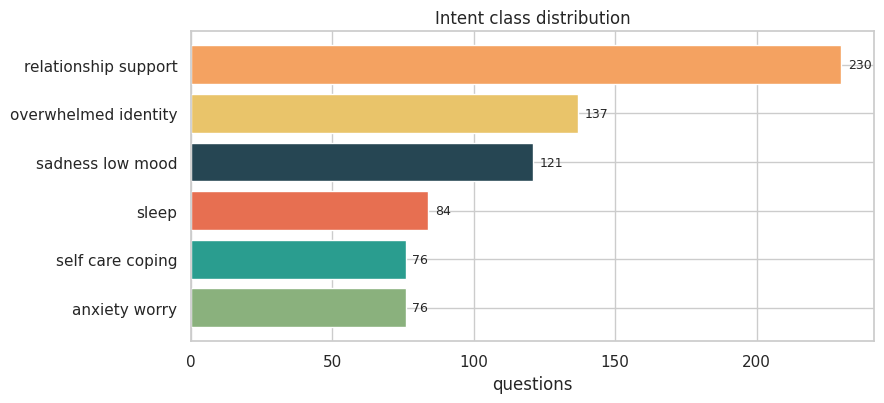

In [7]:
order = dist.sort_values().index
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(range(len(order)), dist[order].values, color=[PALETTE[intent_names.index(i)] for i in order])
ax.set_yticks(range(len(order))); ax.set_yticklabels([i.replace("_", " ") for i in order])
for yloc, v in enumerate(dist[order].values):
    ax.text(v + dist.max() * 0.01, yloc, f"{v}", va="center", fontsize=9)
ax.set_title("Intent class distribution"); ax.set_xlabel("questions")
plt.tight_layout(); save_fig("class_balance.png"); plt.show()

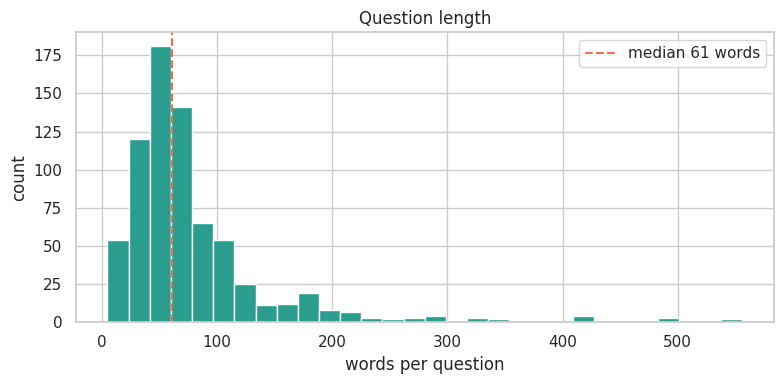

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data["ctx_words"], bins=30, color=TEAL, edgecolor="white")
ax.axvline(data["ctx_words"].median(), color=CORAL, linestyle="--", label=f"median {int(data['ctx_words'].median())} words")
ax.set_xlabel("words per question"); ax.set_ylabel("count"); ax.set_title("Question length"); ax.legend()
plt.tight_layout(); save_fig("question_length.png"); plt.show()

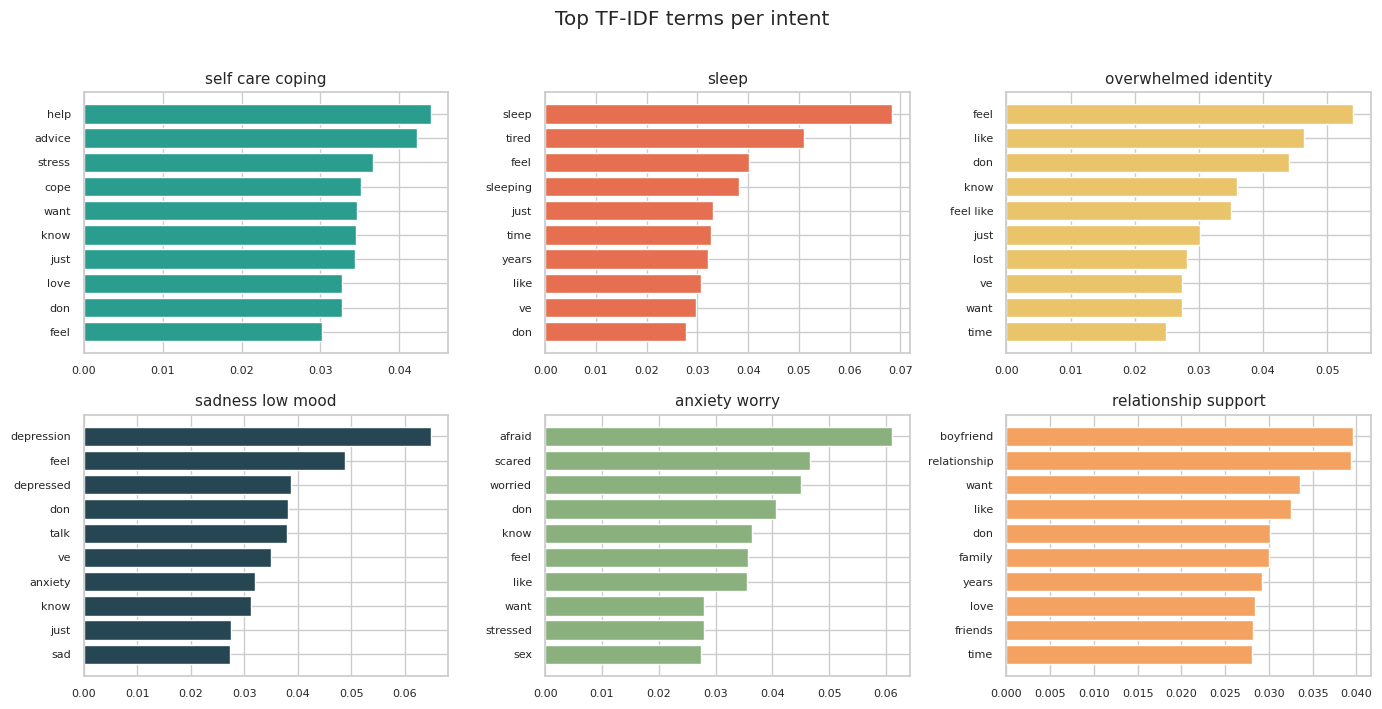

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
viz_tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=3, max_features=4000, sublinear_tf=True)
Xv = viz_tfidf.fit_transform(data["Context"])
terms = np.array(viz_tfidf.get_feature_names_out())
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, intent in zip(axes.ravel(), intent_names):
    mask = (data["intent"] == intent).values
    mean_tfidf = np.asarray(Xv[mask].mean(axis=0)).ravel()
    top = mean_tfidf.argsort()[-10:]
    ax.barh(terms[top], mean_tfidf[top], color=PALETTE[intent_names.index(intent)])
    ax.set_title(intent.replace("_", " "), fontsize=11); ax.tick_params(labelsize=8)
fig.suptitle("Top TF-IDF terms per intent", y=1.01)
plt.tight_layout(); save_fig("top_terms.png"); plt.show()

## 6. Add Kinyarwanda text

Models 2 and 3 work directly in Kinyarwanda. The questions were translated once with NLLB-200 and cached; we merge that translation onto the labeled rows.

In [10]:
kin = pd.read_csv(KIN_URL)
data = data.merge(kin[["Context", "context_rw"]], on="Context", how="inner").reset_index(drop=True)
labels = sorted(data["intent"].unique())
l2i = {l: i for i, l in enumerate(labels)}
y = data["intent"].values
yi = data["intent"].map(l2i).values
EN = data["Context"].values
RW = data["context_rw"].values
print(f"modeling dataset: {len(data):,} rows with English + Kinyarwanda + intent")

modeling dataset: 724 rows with English + Kinyarwanda + intent


## 7. Train and test split

A stratified 80/20 split, shared across all models so the comparison is fair.

In [11]:
idx = np.arange(len(data))
tr, te = train_test_split(idx, test_size=0.20, random_state=RNG, stratify=y)
print("train:", len(tr), "| test:", len(te))

train: 579 | test: 145


## 8. Baseline: Naive Bayes (English TF-IDF)

A simple reference the real models must beat.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion
# word n-grams + character n-grams; char_wb captures sub-word morphology (helps both languages)
tfidf_en = FeatureUnion([
    ("word", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
])
Xtr = tfidf_en.fit_transform(EN[tr]); Xte = tfidf_en.transform(EN[te])
nb = MultinomialNB().fit(Xtr, y[tr])
results["Baseline (Naive Bayes)"] = score(y[te], nb.predict(Xte))
print("Baseline (Naive Bayes):", results["Baseline (Naive Bayes)"])
save_json("naive_bayes_baseline.json", {"Naive Bayes (baseline)": results["Baseline (Naive Bayes)"]})

## 9. Model 1: TF-IDF + Logistic Regression (English)

The deployed model: linear, class-weighted, interpretable. Features are **word + character n-grams** (char n-grams capture sub-word morphology and lift macro-F1).

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG).fit(Xtr, y[tr])
p1 = clf.predict(Xte)
results["Model 1: TF-IDF + LogReg (English)"] = score(y[te], p1)
print("Model 1:", results["Model 1: TF-IDF + LogReg (English)"], "\n")
print(classification_report(y[te], p1, zero_division=0))
save_json("baseline_metrics.json", {"Logistic Regression": results["Model 1: TF-IDF + LogReg (English)"]})

## 10. Model 2: Multilingual MiniLM embeddings + MLP (Kinyarwanda)

Dense multilingual embeddings of the Kinyarwanda text, classified with an MLP.

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.neural_network import MLPClassifier
encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
emb = encoder.encode(RW.tolist(), show_progress_bar=False, normalize_embeddings=True)
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=RNG).fit(emb[tr], y[tr])
results["Model 2: MiniLM + MLP (Kinyarwanda)"] = score(y[te], mlp.predict(emb[te]))
print("Model 2:", results["Model 2: MiniLM + MLP (Kinyarwanda)"])
save_json("model2_metrics.json", {"Model 2: MiniLM + MLP (Kinyarwanda)": results["Model 2: MiniLM + MLP (Kinyarwanda)"]})

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model 2: {'accuracy': 0.4069, 'precision_macro': 0.3887, 'recall_macro': 0.3939, 'f1_macro': 0.3881}
saved reports/model2_metrics.json


## 11. Model 3: AfroXLMR fine-tune (Kinyarwanda)

A transformer pretrained on Kinyarwanda, fine-tuned to classify directly (no translation hop). Needs a GPU.

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1/4  avg_loss=1.789
epoch 2/4  avg_loss=1.775
epoch 3/4  avg_loss=1.711
epoch 4/4  avg_loss=1.642

Model 3: {'accuracy': 0.3241, 'precision_macro': 0.2708, 'recall_macro': 0.2588, 'f1_macro': 0.239} 

                      precision    recall  f1-score   support

       anxiety_worry       0.20      0.07      0.10        15
overwhelmed_identity       0.33      0.14      0.20        28
relationship_support       0.40      0.67      0.50        46
    sadness_low_mood       0.14      0.04      0.06        24
    self_care_coping       0.38      0.33      0.36        15
               sleep       0.16      0.29      0.21        17

            accuracy                           0.32       145
           macro avg       0.27      0.26      0.24       145
        weighted avg       0.30      0.32      0.28       145

saved reports/kinyarwanda_finetune_metrics.json


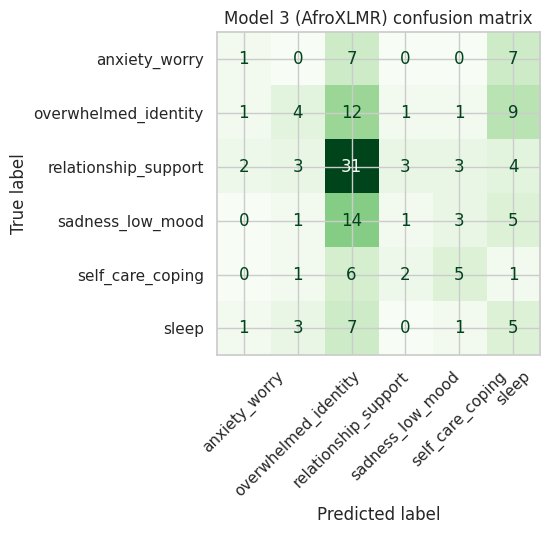

In [15]:
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SAVE_MODEL = False  # set True to also export the fine-tuned weights (large, ~1.1GB)
MODEL = "Davlan/afro-xlmr-base"
MAXLEN, BATCH, EPOCHS, LR = 128, 16, 4, 2e-5
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=len(labels)).to(DEVICE)

class IntentDataset(Dataset):
    def __init__(self, texts, ys):
        self.enc = tokenizer(list(texts), truncation=True, padding="max_length", max_length=MAXLEN, return_tensors="pt")
        self.y = torch.tensor(list(ys))
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.y[i]
        return item

counts = np.bincount(yi[tr], minlength=len(labels)); counts[counts == 0] = 1
weights = torch.tensor(counts.sum() / (len(labels) * counts), dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
train_dl = DataLoader(IntentDataset(RW[tr], yi[tr]), batch_size=BATCH, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * len(train_dl) * EPOCHS), len(train_dl) * EPOCHS)

for epoch in range(EPOCHS):
    model.train(); total = 0.0
    for batch in train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        loss = loss_fn(out.logits, batch["labels"])
        loss.backward(); optimizer.step(); scheduler.step(); total += loss.item()
    print(f"epoch {epoch + 1}/{EPOCHS}  avg_loss={total / len(train_dl):.3f}")

model.eval(); preds = []
for batch in DataLoader(IntentDataset(RW[te], yi[te]), batch_size=32):
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        preds += model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.argmax(-1).cpu().tolist()
results["Model 3: AfroXLMR fine-tune (Kinyarwanda)"] = score(yi[te], preds)
print("\nModel 3:", results["Model 3: AfroXLMR fine-tune (Kinyarwanda)"], "\n")
print(classification_report(yi[te], preds, target_names=labels, zero_division=0))
save_json("kinyarwanda_finetune_metrics.json", {"Model 3: AfroXLMR fine-tune (Kinyarwanda)": results["Model 3: AfroXLMR fine-tune (Kinyarwanda)"]})

cm = confusion_matrix(yi[te], preds, labels=list(range(len(labels))))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Greens", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Model 3 (AfroXLMR) confusion matrix")
plt.tight_layout(); save_fig("model3_confusion.png"); plt.show()

if SAVE_MODEL:
    model.save_pretrained("models/afroxlmr-intent"); tokenizer.save_pretrained("models/afroxlmr-intent")
    print("saved models/afroxlmr-intent")

## 12. Model comparison

In [ ]:
comparison = pd.DataFrame({k: {"Accuracy": v["accuracy"], "F1": v["f1_macro"]} for k, v in results.items()}).T
print(comparison.to_string())
comparison.to_csv(os.path.join(REPORTS, "model_comparison.csv"))
ax = comparison.plot.bar(figsize=(9, 4.5), rot=15, color=[TEAL, CORAL], edgecolor="white")
ax.set_ylim(0, 1.0); ax.set_ylabel("score"); ax.set_title("Model comparison")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); save_fig("model_comparison.png"); plt.show()

## 13. Cross-lingual degradation

Holding the model fixed, how much accuracy does the move to machine-translated Kinyarwanda cost? This gap is the central measurement.

In [ ]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import cross_validate, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=RNG)
def cross_lingual_f1(stop_words, column):
    pipe = Pipeline([
        ("feats", FeatureUnion([
            ("word", TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)),
            ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
        ])),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG)),
    ])
    r = cross_validate(pipe, data[column], y, cv=cv, scoring=["accuracy", "f1_macro"])
    return r["test_accuracy"].mean(), r["test_f1_macro"].mean()

en_acc, en_f1 = cross_lingual_f1("english", "Context")
rw_acc, rw_f1 = cross_lingual_f1(None, "context_rw")
print(f"English:     acc={en_acc:.3f}  F1={en_f1:.3f}")
print(f"Kinyarwanda: acc={rw_acc:.3f}  F1={rw_f1:.3f}")
print(f"Degradation: dF1={en_f1 - rw_f1:+.3f} ({(1 - rw_f1 / en_f1) * 100:.0f}% relative)")
save_json("cross_lingual_degradation.json", {
    "english": {"accuracy": round(float(en_acc), 4), "f1_macro": round(float(en_f1), 4)},
    "kinyarwanda_mt": {"accuracy": round(float(rw_acc), 4), "f1_macro": round(float(rw_f1), 4)},
    "delta_f1_macro": round(float(en_f1 - rw_f1), 4)})
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["English", "Kinyarwanda"], [en_f1, rw_f1], color=[TEAL, CORAL])
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 0.8); ax.set_title("Cross-lingual degradation (same model)")
for i, value in enumerate([en_f1, rw_f1]):
    ax.text(i, value + 0.01, f"{value:.3f}", ha="center")
plt.tight_layout(); save_fig("cross_lingual_degradation.png"); plt.show()

## 14. Confidence-gate calibration

The app abstains when the top class probability is low. This shows the coverage vs accuracy trade-off for choosing that threshold.

In [ ]:
proba = clf.predict_proba(Xte)
pred = clf.classes_[proba.argmax(1)]
conf = proba.max(1)
rows = []
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    answered = conf >= t
    acc = accuracy_score(y[te][answered], pred[answered]) if answered.any() else float("nan")
    rows.append({"threshold": t, "coverage": round(float(answered.mean()), 3), "acc_on_answered": round(float(acc), 3)})
sweep = pd.DataFrame(rows).set_index("threshold")
print(sweep.to_string())
sweep.to_csv(os.path.join(REPORTS, "threshold_sweep.csv"))

## 15. Save everything

In [19]:
save_json("all_metrics.json", results)
import shutil
shutil.make_archive("umubyeyi_outputs", "zip", root_dir=".", base_dir="reports")
print("bundled -> umubyeyi_outputs.zip")
if IN_COLAB:
    from google.colab import files
    files.download("umubyeyi_outputs.zip")
    print("Downloaded. Extract it at your repo root so reports/ is populated.")
else:
    print("Saved under reports/ (and bundled into umubyeyi_outputs.zip).")

saved reports/all_metrics.json
bundled -> umubyeyi_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded. Extract it at your repo root so reports/ is populated.
